# Importando as biblitecas


In [101]:
import utils as ut
import files as fl
import qc
from qc_freeze import QCFreezeConfig
from configuration import Configuration
from evidence_policy import EvidencePolicy
from pathlib import Path
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


Começando o run_main
- Criando as variáveis do sistema

In [2]:
output_directory = 'output/'
input_data_directory = 'data/'
metadata_path = 'data/meta.xlsx'

In [3]:
# IF para ver se entrou com o texto do critério de seleção para o run. Esse texto deve ter mais que 10 caractéres, por que exigir isso?
# if not isinstance(selection_criterion, str) or len(selection_criterion.strip()) < 10:
#         raise ValueError("selection_criterion obrigatorio (>=10 caracteres).")
configurations = Configuration() # Essa classe vai carregar todas as configurações
QC_freeze =  QCFreezeConfig()
policy =  EvidencePolicy()

# Essa função só vai verificar se as configurações do QC e Evidence Policy estão OK! Basicamente o policy.mode tem que ser 'integration' (é o único modo possível) e que o QC_freeze.thresholds_frozen = False
# Acho que podemos suprimir essa burocracia, melhor gerar um único arquivo de configuração ao invez de vários arquivos de configurações estáticas.
qc.assert_qc_thresholds_frozen(QC_freeze, policy)


- Criando diretórios de saída.

In [4]:
out = Path(output_directory)
# melhorando essa criação de diretórios e nome de diretórios
# d_int, d_qual = out / "01_integration", out / "02_quality"
# # d_ana, d_sens = out / "03_analysis", out / "04_sensitivity"
# for d in (d_int, d_qual, d_ana, d_sens):
#         d.mkdir(parents=True, exist_ok=True)

output_directories_name = ["integration","quality", "analysis","sensitivity"]
output_directories = {}
for name in output_directories_name:
    output_directories[name]=out/name;
    output_directories[name].mkdir(parents=True, exist_ok=True)
# print(output_directories)

- Lendo os arquivos de dados e separando os que não tem nome válido dos inválivos

In [5]:
valid_files, invalid_files = fl.list_data_eeg_files(input_data_directory)
print(valid_files)
print(invalid_files)

[PosixPath('data/02010001_still.txt'), PosixPath('data/02010002_still.txt'), PosixPath('data/02010003_still.txt'), PosixPath('data/02010005_still.txt'), PosixPath('data/02010006_still.txt'), PosixPath('data/02010007_still.txt'), PosixPath('data/02010008_still.txt'), PosixPath('data/02010009_still.txt'), PosixPath('data/02010010_still.txt'), PosixPath('data/02010011_still.txt'), PosixPath('data/02010012_still.txt'), PosixPath('data/02010013_still.txt'), PosixPath('data/02010014_still.txt'), PosixPath('data/02010015_still.txt'), PosixPath('data/02010016_still.txt'), PosixPath('data/02010018_still.txt'), PosixPath('data/02010019_still.txt'), PosixPath('data/02010020_still.txt'), PosixPath('data/02010021_still.txt'), PosixPath('data/02010022_still.txt'), PosixPath('data/02010024_still.txt'), PosixPath('data/02010025_still.txt'), PosixPath('data/02010026_still.txt'), PosixPath('data/02010030_still.txt'), PosixPath('data/02010035_still.txt'), PosixPath('data/02010038_still.txt'), PosixPath('

- Lendo os metadados dos arquivos.

In [6]:
# print(metadata_path)
metadata = fl.load_modma_metadata(metadata_path)
# print(metadata)

In [7]:
fp = valid_files[0]
rec = fl.load_modma_file(fp, configurations, fp.name)
print(rec.data_counts[0])

[4297790. 4284976. 4246160. ... 2487998. 2495050. 2501644.]


In [8]:
from utils import verify_sampling_rate
fsv = verify_sampling_rate(rec.data_counts, configurations)
print(fsv)

{'implied_fs_if_peak_is_line_hz': [250.0, 300.0], 'fs_assumed_hz': 250.0, 'fs_is_assumption': True, 'line_peak_hz_under_assumed_fs': 50.0, 'line_peak_prominence_log10': 5.414857355987548, 'fs_verification': 'line_peak_at_expected_frequency', 'fs_supported': True}


# Entendendo o verify_sampling_rate 


/var/folders/32/scy25r9j76ngpzfk1zmvggmm0000gn/T/ipykernel_79523/2744494906.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


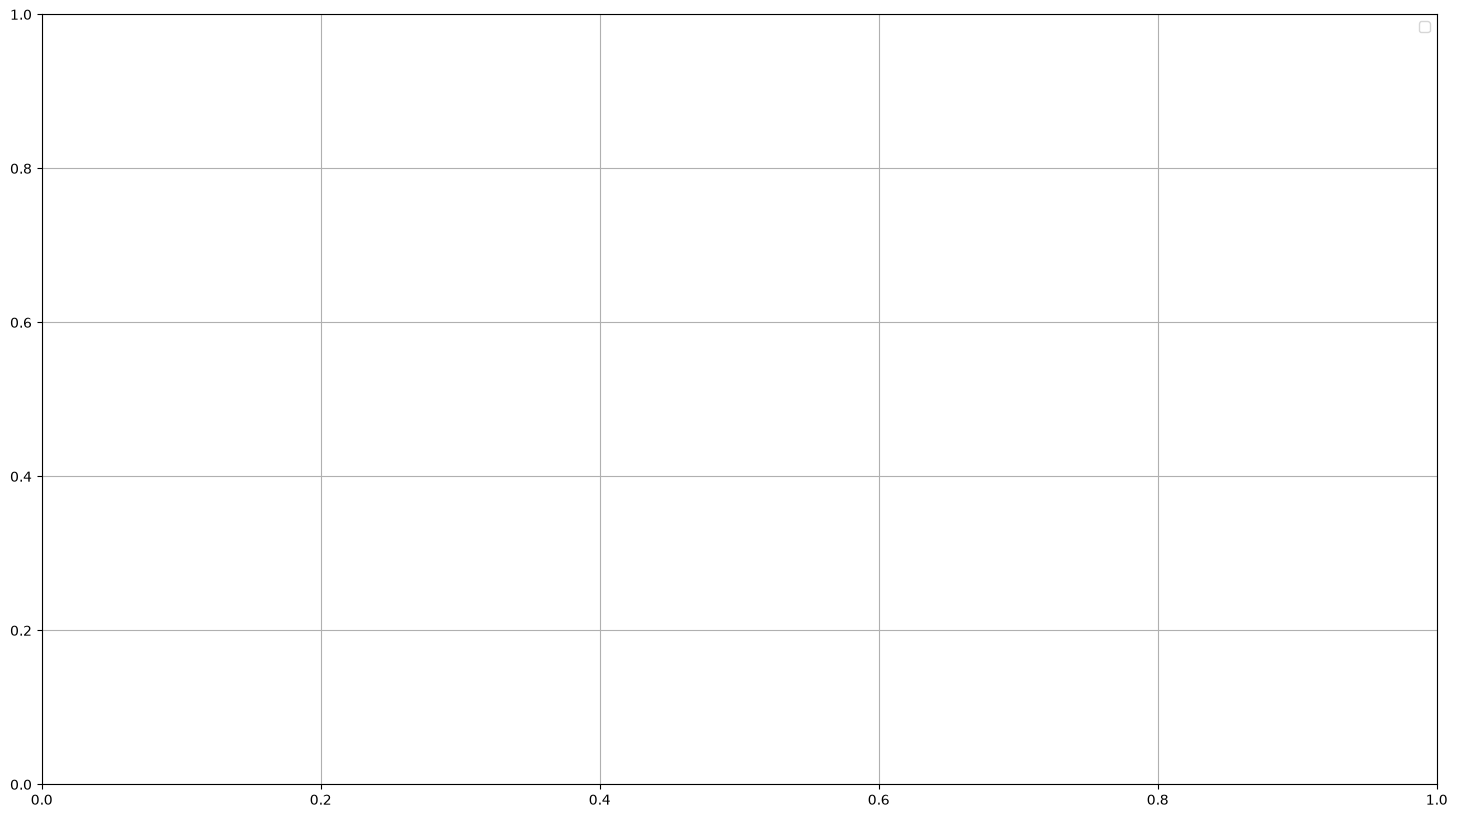

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,10))
plt.grid(True)
plt.legend()

[[4297790. 4284976. 4246160. ... 2487998. 2495050. 2501644.]
 [4797719. 4785183. 4746688. ... 2757175. 2764271. 2770894.]
 [3754634. 3741225. 3701978. ... 1633717. 1641246. 1648069.]]
y.mean
[[4297790. 4284976. 4246160. ... 2487998. 2495050. 2501644.]
 [4797719. 4785183. 4746688. ... 2757175. 2764271. 2770894.]
 [3754634. 3741225. 3701978. ... 1633717. 1641246. 1648069.]]


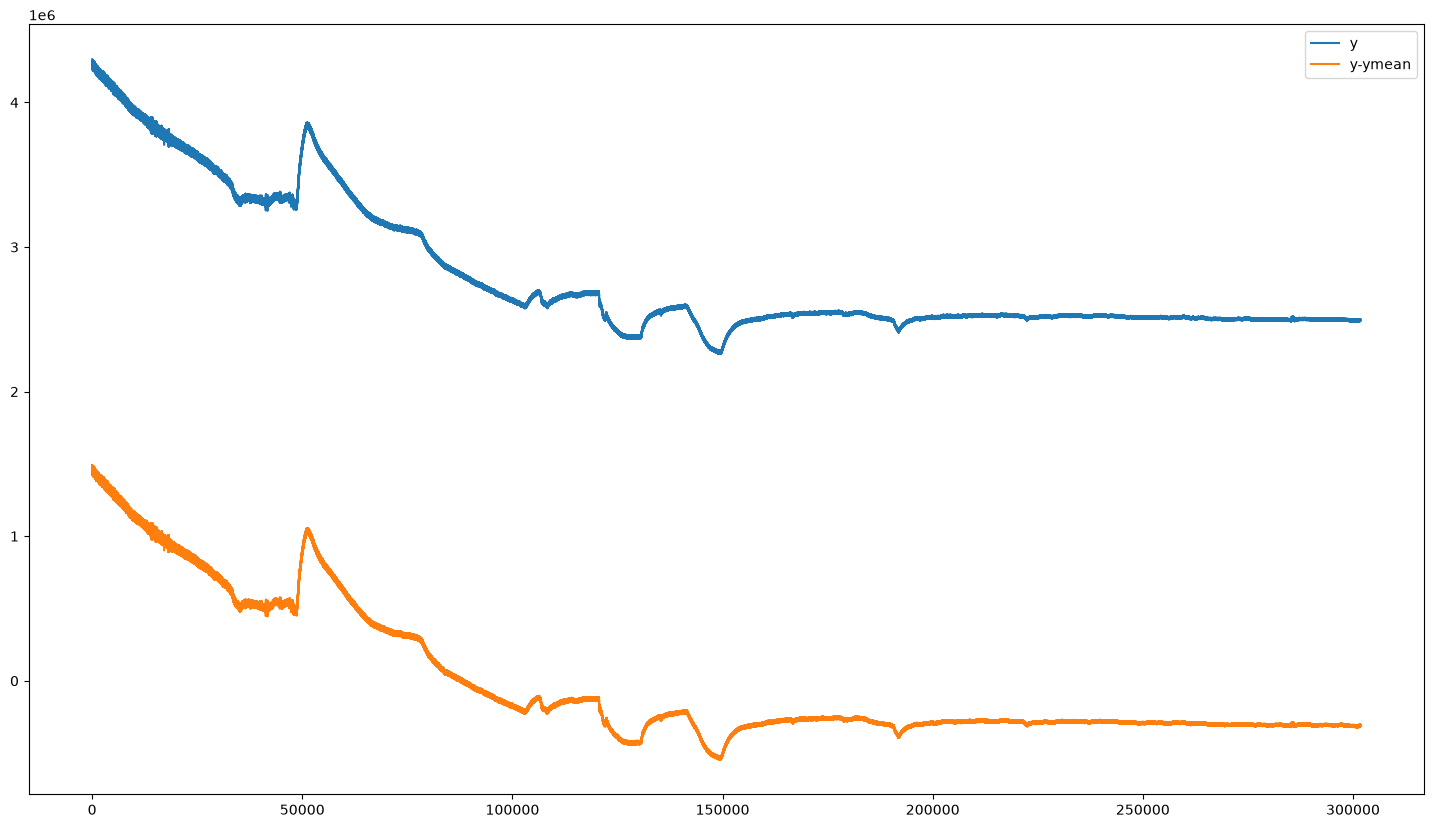

In [10]:
# Garante que os dados é um array e não uma lista ou tupla
y =np.asarray( rec.data_counts, float)
print(y)
# Subtraindo a média de cada valor (POR QUE?)
# y = y-y.mean(axis=-1, keepdims=True)
print('y.mean')
ymean = y.mean(axis=-1, keepdims=True)
y2 = y-ymean
print(y)
plt.figure(figsize=(18,10))
plt.plot(range(len(y[0])), y[0], label='y')
plt.plot(range(len(y2[0])), y2[0], label='y-ymean')
plt.legend()
plt.show()


# chamando psd_continuous
- Estimate power spectral density using Welch’s method

['y2', array([[1492506.6714191 , 1479692.6714191 , 1440876.6714191 , ...,
        -317285.3285809 , -310233.3285809 , -303639.3285809 ],
       [1627029.48797309, 1614493.48797309, 1575998.48797309, ...,
        -413514.51202691, -406418.51202691, -399795.51202691],
       [1710013.64386558, 1696604.64386558, 1657357.64386558, ...,
        -410903.35613442, -403374.35613442, -396551.35613442]],
      shape=(3, 301740))]
['f', array([  0.   ,   0.125,   0.25 , ..., 124.75 , 124.875, 125.   ],
      shape=(1001,))]
['p', array([[3.37863796e+07, 6.62953916e+08, 7.58591642e+07, ...,
        4.70711159e+01, 4.59715462e+01, 2.37678791e+01],
       [3.15816551e+07, 4.66789735e+08, 5.29261710e+07, ...,
        3.83919694e+01, 3.73103082e+01, 1.91335354e+01],
       [1.48264534e+07, 2.83077691e+08, 2.69457069e+07, ...,
        3.96158864e+01, 3.77559047e+01, 1.83640116e+01]], shape=(3, 1001))]
(3, 301740)
['pmedian', array([3.15816551e+07, 4.66789735e+08, 5.29261710e+07, ...,
       3.96158864e

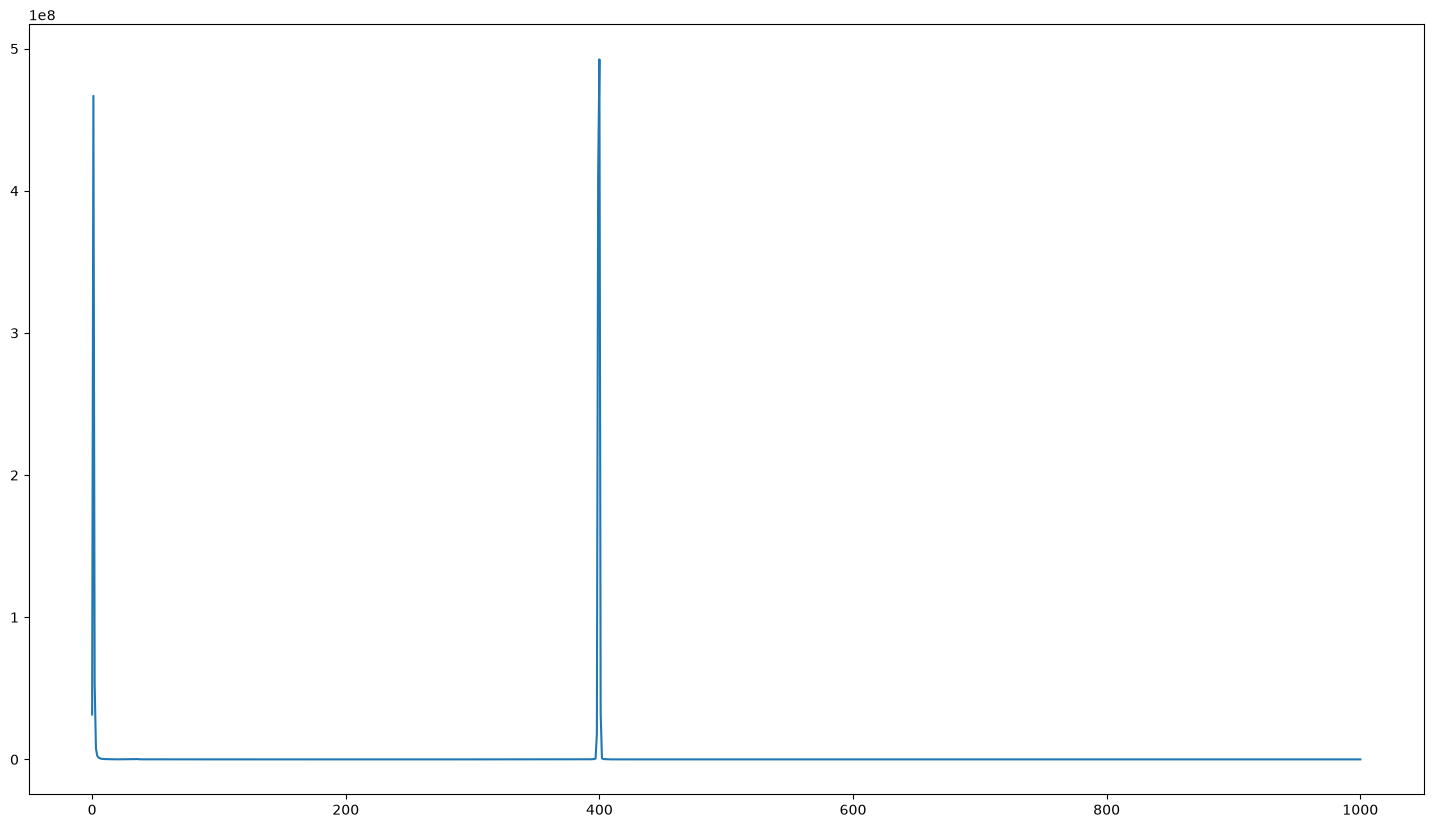

In [11]:
f, p = ut.psd_continuous(y2, configurations.fs, 8)
print(['y2', y2])
print(['f', f])
print(['p',p])
print(y2.shape)
pmedian=np.median(np.atleast_2d(p), axis=0)
print(['pmedian',pmedian])
plt.figure(figsize=(18,10))
plt.plot(range(len(pmedian)), pmedian)
plt.show()


[False False False ...  True  True  True]
[ True  True  True ... False False False]


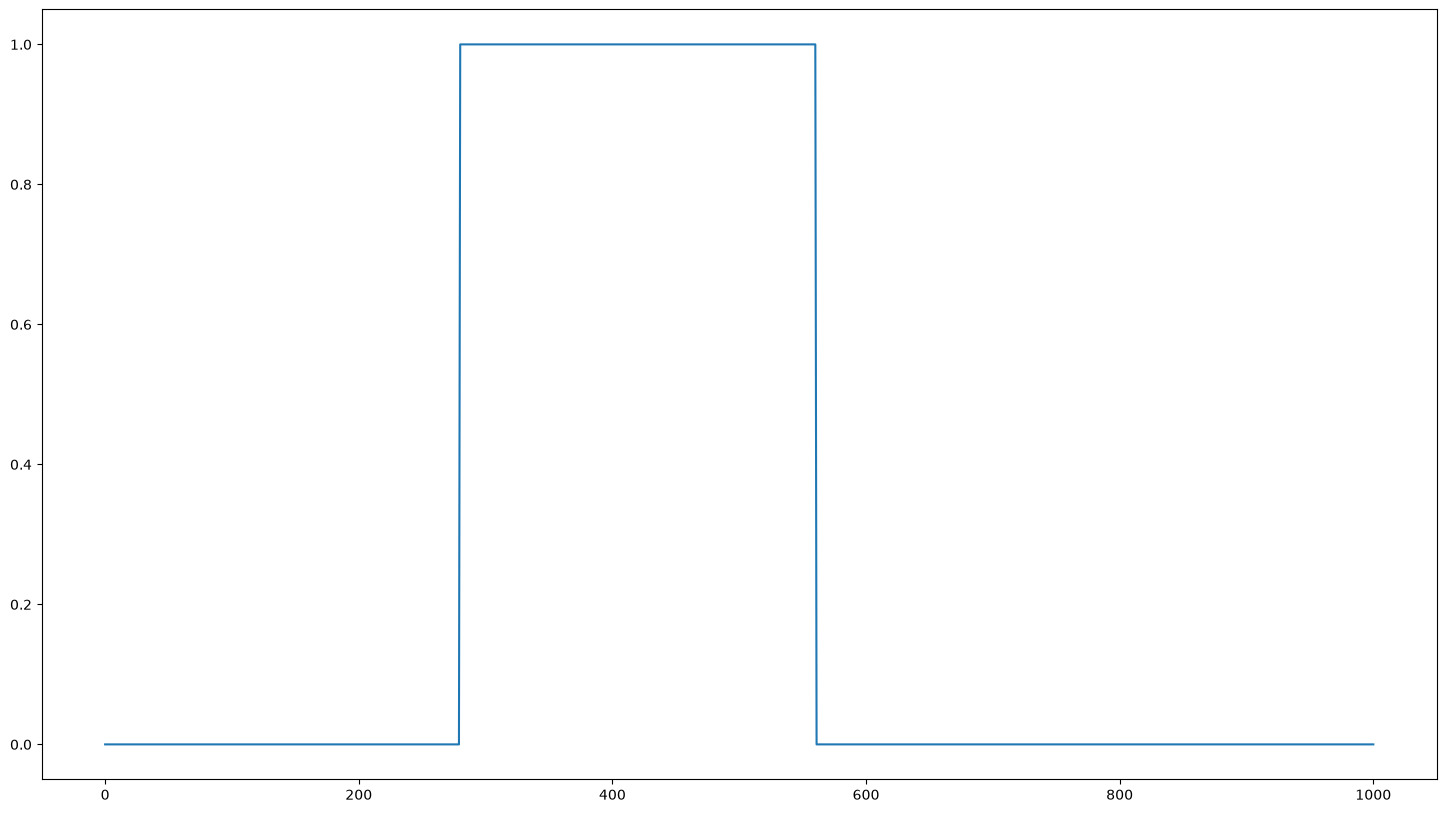

281


In [12]:
fgreater = f>=35.0
print(fgreater)
fminor = f<=min(70, configurations.fs/2. -1.0)
print(fminor)
band = fgreater & fminor
teste=[]
for b in band:
    teste.append( 1 if b else 0)
plt.figure(figsize=(18,10))
plt.plot(range(len(teste)), teste);
plt.show()
print(band.sum())

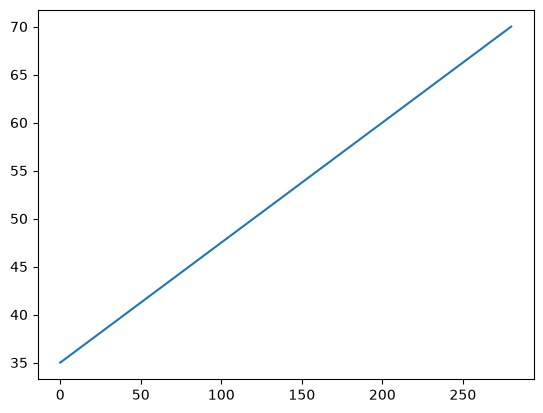

(3, 1001)
(1001,)
['pb', array([3.34147796, 3.43220126, 3.51883907, 3.45467953, 3.40706181,
       3.45134347, 3.46685269, 3.44962823, 3.38442111, 3.43962206,
       3.40908397, 3.35074634, 3.40766403, 3.40545662, 3.38389451,
       3.34033741, 3.37285766, 3.37701722, 3.38667274, 3.43478016,
       3.41901942, 3.38350446, 3.3179101 , 3.32360763, 3.37546896,
       3.4078198 , 3.36396962, 3.33514386, 3.34001149, 3.41056078,
       3.40139573, 3.29177974, 3.26822505, 3.27884314, 3.28797582,
       3.27801889, 3.32138209, 3.3608494 , 3.34424721, 3.27346118,
       3.23699456, 3.29409019, 3.27750448, 3.22638268, 3.11059535,
       3.18836302, 3.2283763 , 3.23402707, 3.25384774, 3.33312613,
       3.36211322, 3.3047794 , 3.34842517, 3.36076188, 3.3876604 ,
       3.21028359, 3.0627072 , 3.28178525, 3.33964445, 3.30613182,
       3.26083298, 3.35765744, 3.3560597 , 3.28264838, 3.06624091,
       3.01945357, 3.13008314, 3.20550262, 3.24496736, 3.16010946,
       3.31792253, 3.38950924, 3.3474

In [13]:
fb = f[band]
# print(['fb', fb, fb.shape])
plt.plot(range(len(fb)),fb)
plt.show()
print(p.shape)
print(band.shape)
pb = np.log10(pmedian[band] + 1e-30)
print(['pb', pb, pb.shape])

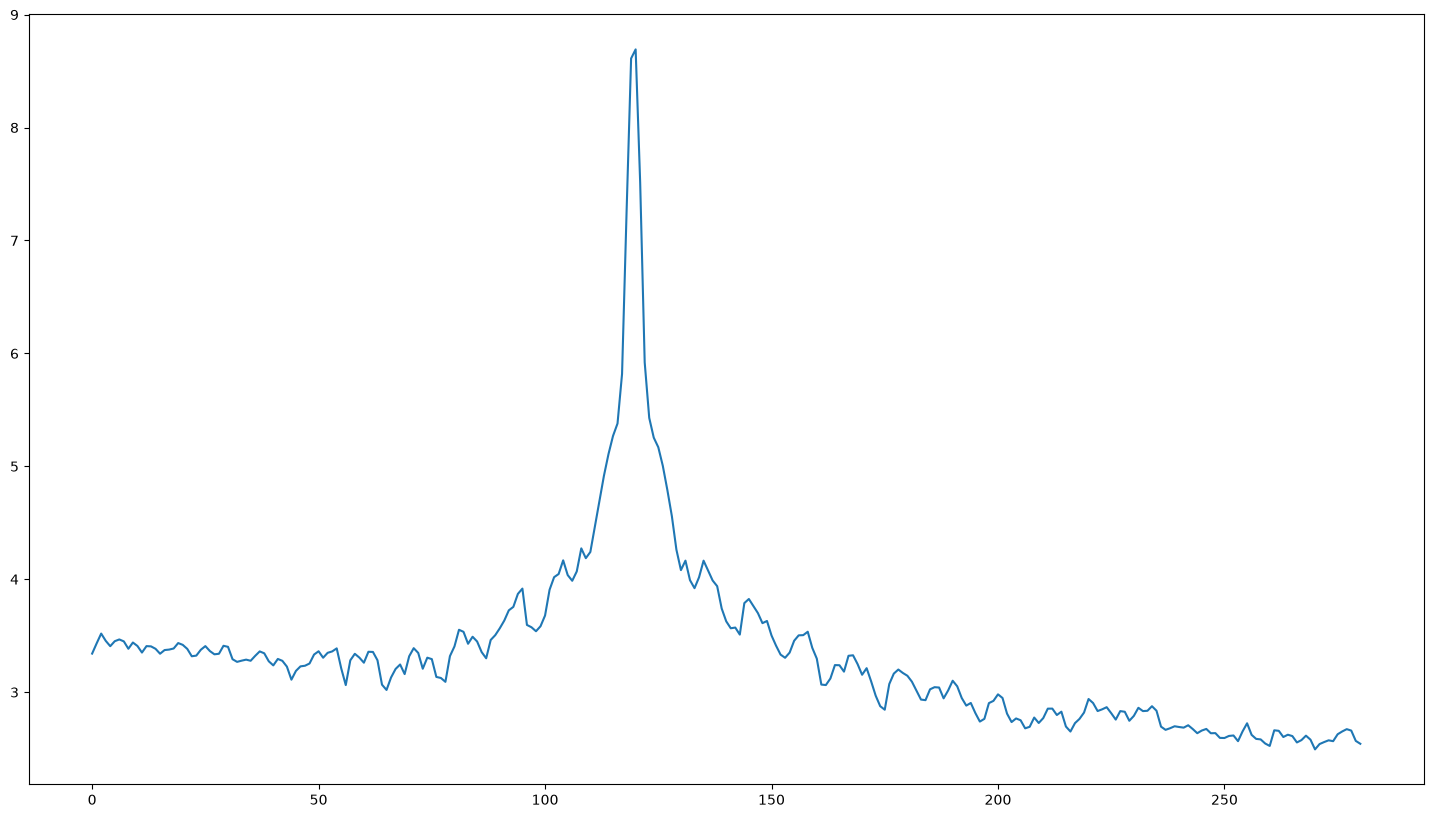

In [14]:
max_index=np.argmax(pb)
plt.figure(figsize=(18,10))
plt.plot(range(len(pb)), pb)
plt.show()

In [15]:
peak_hz=float(fb[max_index])
print(peak_hz);
pb_median = np.median(pb)
print(pb_median)
prominence = pb[max_index]-pb_median
print(prominence)

50.0
3.2775044800263693
5.414857355987548


In [16]:
cand = [c for c in configurations.fs_verification_line_hz
            if abs(peak_hz - c) <= configurations.fs_verification_tol_hz]
print(cand)

print(np.asarray(configurations.fs_verification_line_hz)*(-1)+peak_hz <= configurations.fs_verification_tol_hz )

[50.0]
[ True  True]


In [17]:
has_peak = prominence >= configurations.fs_verification_min_prominence_log10
print(has_peak)

True


# Continuando o RUN

02010001
[[4297790. 4284976. 4246160. ... 2487998. 2495050. 2501644.]
 [4797719. 4785183. 4746688. ... 2757175. 2764271. 2770894.]
 [3754634. 3741225. 3701978. ... 1633717. 1641246. 1648069.]]
(301740,)
(3, 300740)
{'notch_mode': 'auto', 'notch_applied': True, 'line_ratio_pre': 128.2970315721516, 'line_ratio_post': 0.00028814627978310557, 'edge_trim_s': 2.0, 'n_samples_after_trim': 300740}


<Figure size 1800x1000 with 0 Axes>

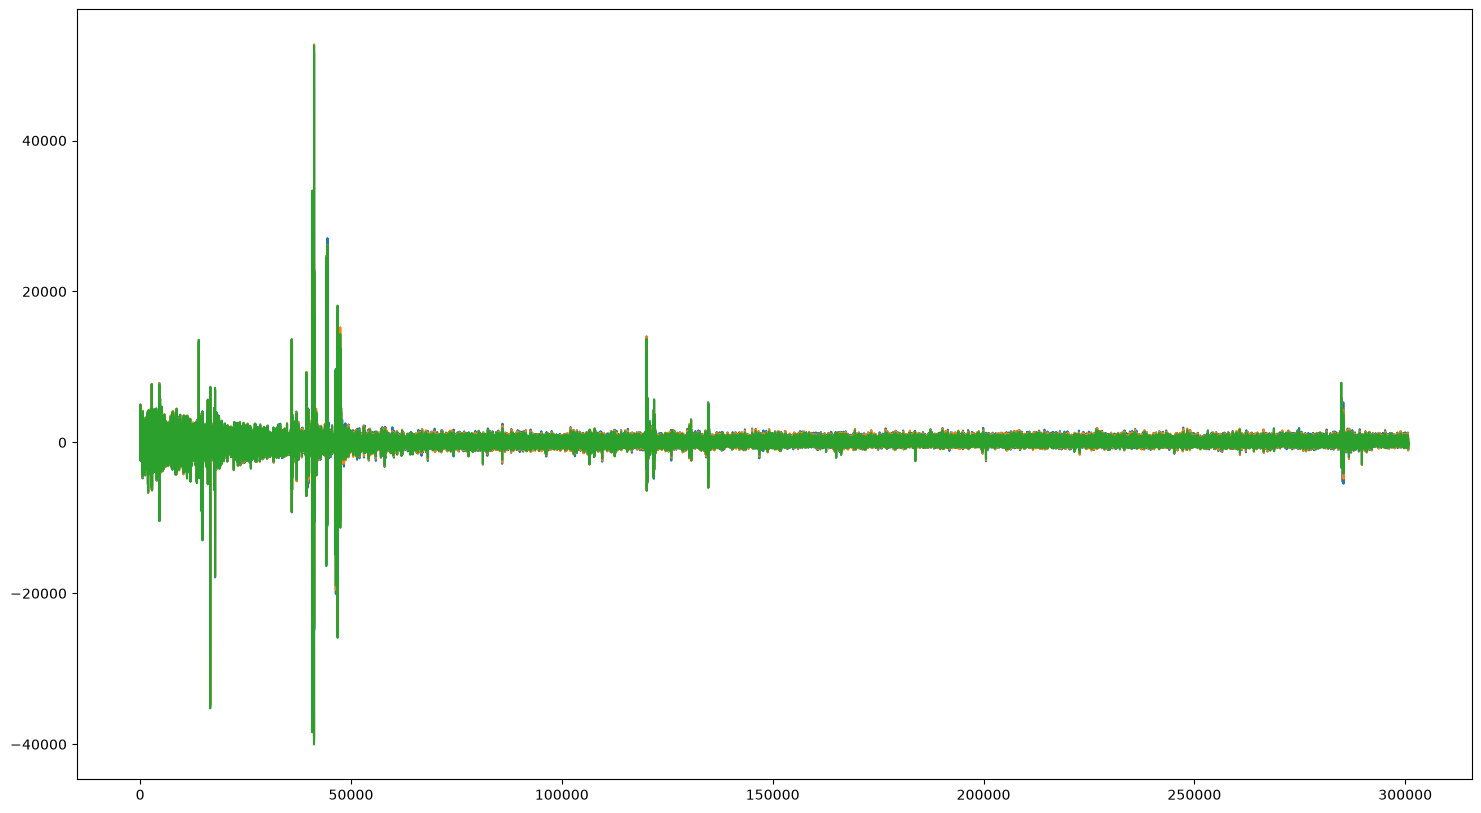

In [18]:
fsv['subject_id']=rec.subject_id
print(fsv['subject_id'])
plt.figure(figsize=(18,10)  )
# print(rec.data_counts[0].shape)
print(rec.data_counts)
print(rec.data_counts[0].shape)
# plt.plot(rec.data_counts[0])
# plt.plot(rec.data_counts[1])
# plt.plot(rec.data_counts[2])
# plt.show()

filt, fdiag = ut.preprocess_continuous(rec.data_counts, configurations, configurations)
# print(filt)
print(filt.shape)
print(fdiag)
plt.figure(figsize=(18,10))
plt.plot(filt[0])
plt.plot(filt[1])
plt.plot(filt[2])
plt.show()


## O que faz o preprocess_continuous?

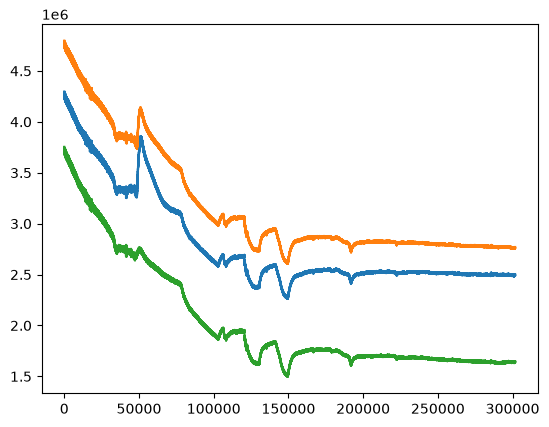

In [19]:
y = np.asarray(rec.data_counts, float)
plt.plot(y[0])
plt.plot(y[1])
plt.plot(y[2])
plt.show()

In [20]:
from utils import line_noise_ratio
ymean = y - y.mean(axis=-1, keepdims=True)
pre_ratio = line_noise_ratio(ymean, configurations.fs, configurations.notch_hz or 50)
print(pre_ratio)

128.2970315721516


In [21]:
if configurations.notch_mode == "always":
    do_notch = configurations.notch_hz is not None
elif configurations.notch_mode == "never":
    do_notch = False
else:
    do_notch = (configurations.notch_hz is not None) and (pre_ratio > configurations.notch_line_ratio_threshold)
print(do_notch)

True


[[1479844.01039055 1470003.36843787 1448155.30433903 ... -312274.34021821
  -309970.26808731 -308406.84534836]
 [1614450.44333374 1604814.29731896 1583195.47242489 ... -408567.58456351
  -406135.28995818 -404487.76626918]
 [1697095.87895168 1687002.56188943 1664960.30436568 ... -405724.83857311
  -403164.31681624 -401515.66515807]]


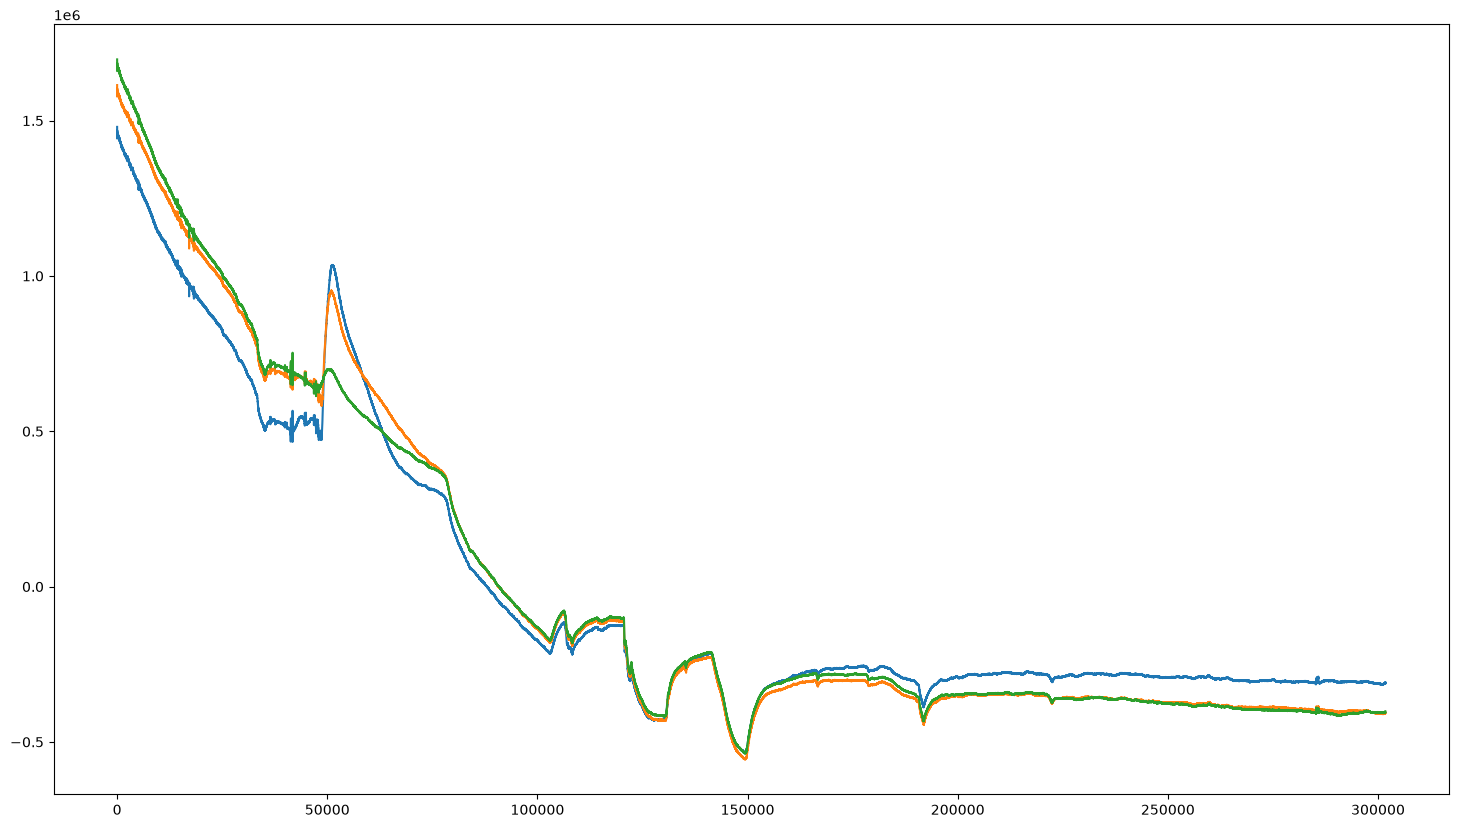

In [22]:
# print(ymean);
# print([configurations.notch_hz, configurations.notch_q, configurations.fs])
bn, an = ut.iirnotch(configurations.notch_hz, Q=configurations.notch_q, fs=configurations.fs)
yfilt = ut.filtfilt(bn, an, ymean, axis=-1)

# print(bn)
# print(an)
# print(ymean);
# plt.plot(bn)
# plt.plot(an)
# plt.show()
print(yfilt)
plt.figure(figsize=(18,10))
plt.plot(yfilt[0])
plt.plot(yfilt[1])
plt.plot(yfilt[2])
plt.show()


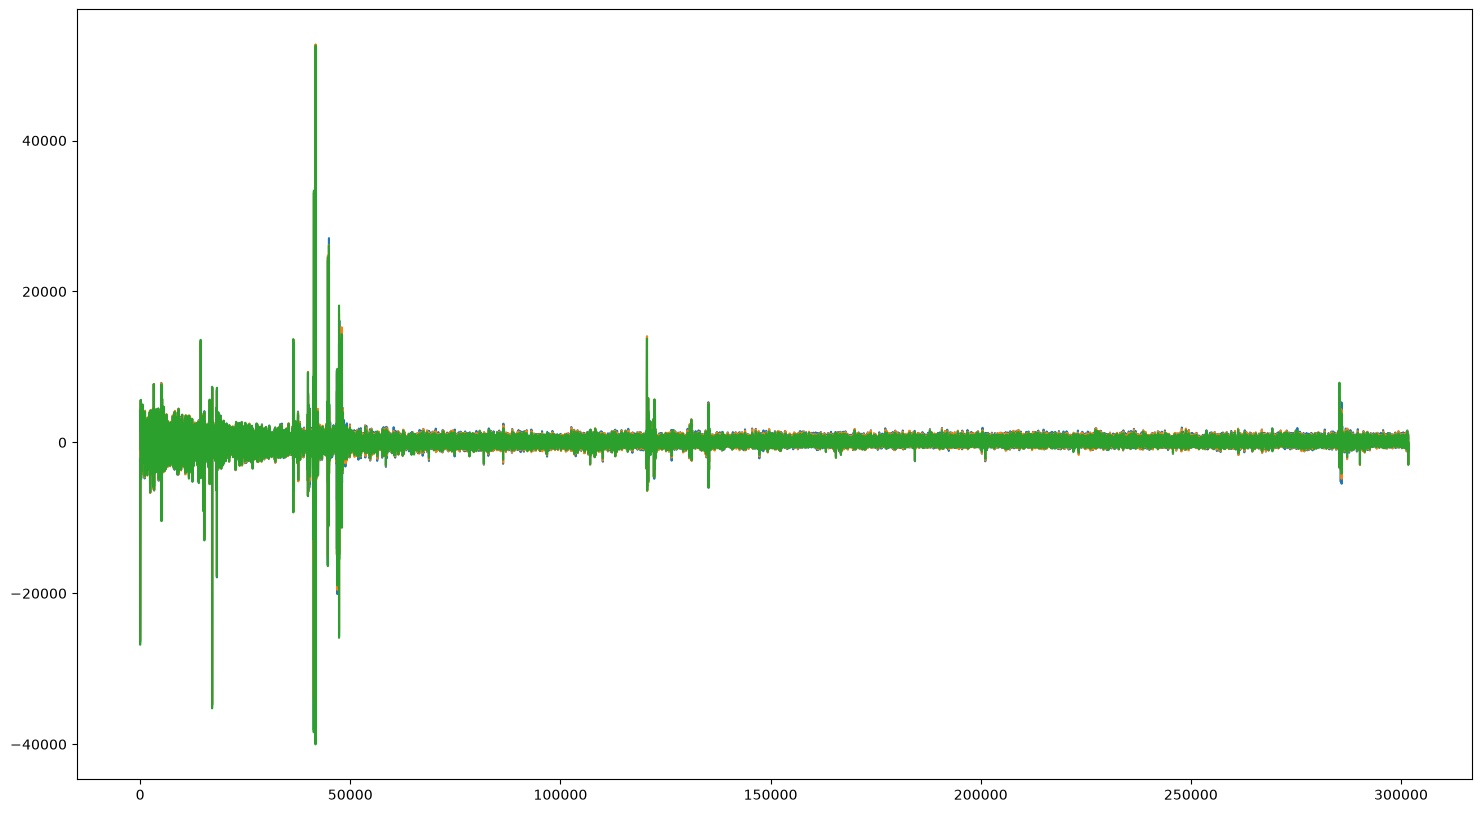

In [23]:
from scipy.signal import butter, filtfilt
lo, hi = configurations.bandpass_hz
nyq = configurations.fs*0.5
b, a = butter(configurations.filter_order, [lo / nyq, hi / nyq], btype="band")
band_filtered = filtfilt(b, a, yfilt, axis=-1)
plt.figure(figsize=(18,10))
plt.plot(band_filtered[0])
plt.plot(band_filtered[1])
plt.plot(band_filtered[2])
plt.show()

(3, 301740)
500
(3, 300740)


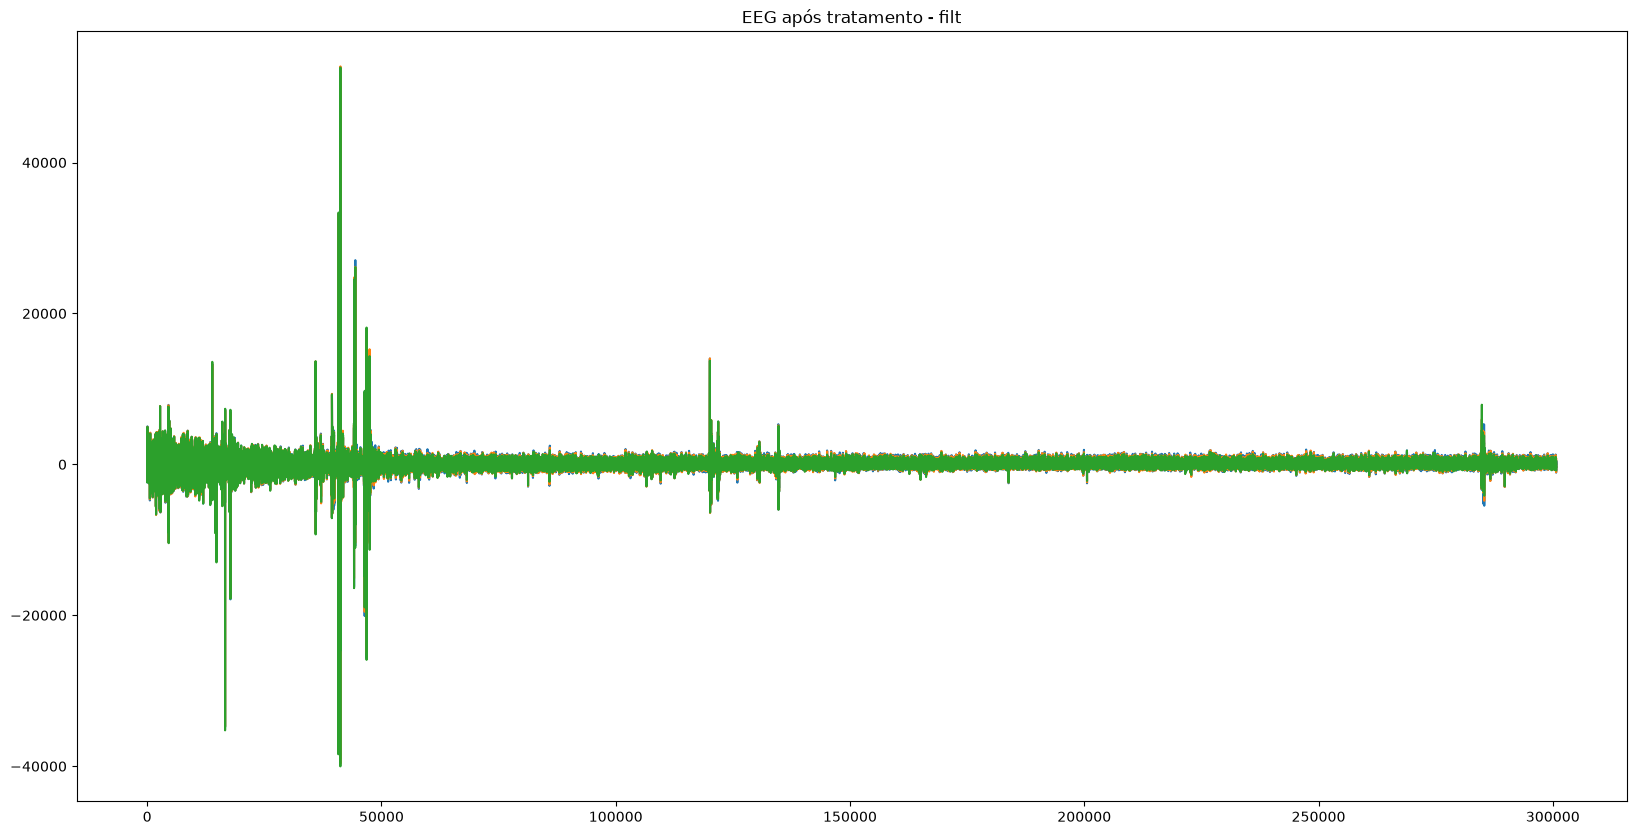

In [24]:
print(band_filtered.shape)
k=int(round(configurations.edge_trim_seconds*configurations.fs))
print(k)
band_filtered_cutted = band_filtered[:, k:-k]
print(band_filtered_cutted.shape)
plt.figure(figsize=(20,10))
plt.title('EEG após tratamento - filt')
# plt.xlim(0,5000)
plt.plot(band_filtered_cutted[0])
plt.plot(band_filtered_cutted[1])
plt.plot(band_filtered_cutted[2])
plt.show()

## Continuando o RUN
## Block_profile

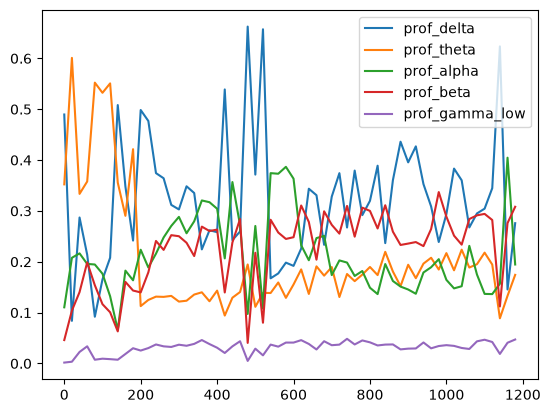

In [104]:

prof = ut.block_profile(filt, configurations.fs, configurations.block_seconds)
plt.plot(prof['t_start_s'], prof['prof_delta'], label = 'prof_delta')
plt.plot(prof['t_start_s'], prof['prof_theta'], label = 'prof_theta')
plt.plot(prof['t_start_s'], prof['prof_alpha'], label = 'prof_alpha')
plt.plot(prof['t_start_s'], prof['prof_beta'], label = 'prof_beta')
plt.plot(prof['t_start_s'], prof['prof_gamma_low'], label = 'prof_gamma_low')
plt.legend()
# print(prof)
# prof.plot(figure=(18,10))

In [ ]:
from scipy.signal import welch
filtered = filt
# block_seconds = configurations.block_seconds
# fs = configurations.fs
block_seconds = 20.0
fs = 250
n = int(round(block_seconds * fs))
nb = filtered.shape[1] // n
rows = []
for i in range(nb):
    seg = filtered[:, i * n:(i + 1) * n]
    # print(min(4.0,block_seconds))
    nperseg_s = min(4.0, block_seconds)
    nper = min(int(round(nperseg_s * fs)), seg.shape[-1])
    print(seg.shape[-1])
    print(nper)
    print(nperseg_s)
    f, p = welch(seg, fs=fs, nperseg=nper, noverlap=nper // 2, detrend="constant", axis=-1)
    print(i)
    print('------------------------------')
    print(f)
    print(p)
    print('***************************************')
    

5000
1000
4.0
0
------------------------------
[  0.     0.25   0.5    0.75   1.     1.25   1.5    1.75   2.     2.25
   2.5    2.75   3.     3.25   3.5    3.75   4.     4.25   4.5    4.75
   5.     5.25   5.5    5.75   6.     6.25   6.5    6.75   7.     7.25
   7.5    7.75   8.     8.25   8.5    8.75   9.     9.25   9.5    9.75
  10.    10.25  10.5   10.75  11.    11.25  11.5   11.75  12.    12.25
  12.5   12.75  13.    13.25  13.5   13.75  14.    14.25  14.5   14.75
  15.    15.25  15.5   15.75  16.    16.25  16.5   16.75  17.    17.25
  17.5   17.75  18.    18.25  18.5   18.75  19.    19.25  19.5   19.75
  20.    20.25  20.5   20.75  21.    21.25  21.5   21.75  22.    22.25
  22.5   22.75  23.    23.25  23.5   23.75  24.    24.25  24.5   24.75
  25.    25.25  25.5   25.75  26.    26.25  26.5   26.75  27.    27.25
  27.5   27.75  28.    28.25  28.5   28.75  29.    29.25  29.5   29.75
  30.    30.25  30.5   30.75  31.    31.25  31.5   31.75  32.    32.25
  32.5   32.75  33.    33.25  

['prof', array([0.35893402, 0.31580607, 0.16640535, 0.13982164, 0.01903291])]
(129,)
(3, 129)


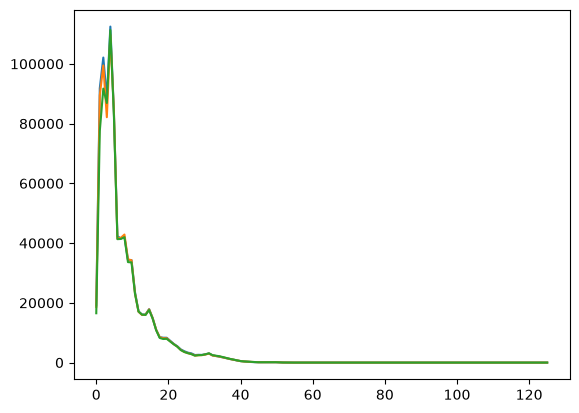

In [67]:
breaks = 256
f, p = welch(filtered, fs=250, nperseg=breaks, noverlap=breaks*.5, detrend="constant", axis=-1)
prof = ut.spectral_profile(filtered, 250)
print(['prof', prof])
print(f.shape)
print(p.shape)
# p = p / max(max(p[0]), max(p[1]), max(p[2]))
plt.plot(f,p[0])
plt.plot(f,p[1])
plt.plot(f,p[2])
plt.show()

In [86]:
from vars import PROFILE_BANDS
print(PROFILE_BANDS)
i = 0
seg = filtered[:, i*n:(i+1) * n]
f, p = welch(seg, fs=fs, nperseg=nper, noverlap=nper // 2, detrend="constant", axis=-1)
prof = ut.spectral_profile(seg, 250)

v = np.array([])
for _, lo, hi in PROFILE_BANDS:
    band_shr = ut.band_share(f, p, lo, hi, (1.0, 40.0))
    num = p[..., (f>=lo) & (f<hi)].sum(axis=-1) # axis=-1 está realizando a soma por coluna.
    den = p[..., (f>=1) & (f<40)].sum(axis=-1)+1e-30
    v=np.append(v, np.mean(num/den))
    s = v.sum()
    # print( 'Freq de:'+str(lo)+" até: "+str(hi))
    # print(v)
    # print(s)
    # # print(['numerdor',num])
    # # print(['denominador',den])
    # # print(['teste',num2])
    # print(['num/den',num/den])
    # print(['band_shr',band_shr])
    # print(np.mean(num/den))
    # print(band_shr)
    # print(np.mean(band_shr))
s = v.sum()
print(v.shape)
print(v.size)
print(v/s)
print(prof)
print(np.full(v.shape, 1.0/v.size))
print({
            "block_index": i, 
            "t_start_s": i * block_seconds,
            "rms_counts": float(np.median(np.sqrt((seg ** 2).mean(axis=1)))),
            "ocular_index": float(np.median(ut.band_share(f, p, 0.5, 3.0, (1.0, 40.0)))),
            "muscle_ratio": float(
                np.median(ut.band_share(f, p, 20.0, 40.0, (1.0, 40.0)))),
                     **{"prof_%s" % nm: float(prof[j])
                        for j, (nm, _, _) in enumerate(PROFILE_BANDS)}})


# print(prof.shape)
# print('PROF - result')
# print(prof)
# plt.plot(f, p[0])
# plt.plot(f, p[1])
# plt.plot(f, p[2])
# plt.show()
# print(seg.shape)

(('delta', 1.0, 4.0), ('theta', 4.0, 8.0), ('alpha', 8.0, 13.0), ('beta', 13.0, 30.0), ('gamma_low', 30.0, 40.0))
(5,)
5
[0.48963698 0.3522358  0.11042038 0.04599692 0.00170992]
[0.48963698 0.3522358  0.11042038 0.04599692 0.00170992]
[0.2 0.2 0.2 0.2 0.2]
{'block_index': 0, 't_start_s': 0.0, 'rms_counts': 2178.630429194815, 'ocular_index': 0.4599310507308353, 'muscle_ratio': 0.005482995871025238, 'prof_delta': 0.48963697957731583, 'prof_theta': 0.35223579817912226, 'prof_alpha': 0.11042037634343357, 'prof_beta': 0.04599692331769632, 'prof_gamma_low': 0.0017099225824320796}


In [90]:
a = np.array([[1,2,3],[4,5,6]])
print(a)
print(a.transpose())

[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]
